# Aula 2 — Tokenização (prática)

Neste laboratório vamos percorrer o **pipeline completo de tokenização** da biblioteca
[`tokenizers`](https://huggingface.co/docs/tokenizers) da Hugging Face:

```
Normalização → Pré-tokenização → Modelo (BPE) → Pós-processamento
```

**Corpus de referência:** letras de **rock nacional brasileiro**.
O rock BR mistura palavras do português coloquial, neologismos e expressões de
protesto — características que tornam os experimentos de tokenização especialmente
interessantes.

**Objetivos de aprendizagem**

1. Distinguir os diferentes pré-tokenizadores (`Whitespace`, `Punctuation`, `ByteLevel`, `Metaspace`).
2. Treinar um tokenizador BPE do zero e inspecionar o vocabulário.
3. Montar o pipeline de `encode` com normalização e pós-processamento.
4. Comparar as abordagens *ByteLevel* (GPT-2) e *SentencePiece* (mT5).
5. Avaliar a eficiência de um tokenizador com métricas simples.

> 🔧 Ao longo do notebook há células marcadas com **`# TODO (exercício)`**. Complete-as.
> As células de exercício **não vêm com gabarito**.

## Setup

Instale as dependências (no Colab, execute uma vez).

In [19]:
# No Colab/ambiente limpo, descomente a linha abaixo:
# !pip install -q tokenizers transformers pandas

import tokenizers
print("tokenizers:", tokenizers.__version__)

tokenizers: 0.22.2


## Parte 1 — Pré-tokenização

A **pré-tokenização** quebra o texto em pedaços ("palavras") *antes* de o modelo BPE agir.
Cada estratégia decide de forma diferente onde estão as fronteiras e o que fazer com
espaços e pontuação. O retorno é uma lista de `(pedaço, (início, fim))`, onde o par
`(início, fim)` é o *offset* (posição) do pedaço no texto original.

### 1.1 — Whitespace

In [20]:
from tokenizers import Tokenizer, models, pre_tokenizers

tok_ws = Tokenizer(models.BPE())
tok_ws.pre_tokenizer = pre_tokenizers.Whitespace()

# Verso de rock nacional — acento, vírgula, ponto de exclamação
frase = "Não é sobre ter toda beleza do mundo!"
print(tok_ws.pre_tokenizer.pre_tokenize_str(frase))


[('Não', (0, 3)), ('é', (4, 5)), ('sobre', (6, 11)), ('ter', (12, 15)), ('toda', (16, 20)), ('beleza', (21, 27)), ('do', (28, 30)), ('mundo', (31, 36)), ('!', (36, 37))]


### 1.2 — Whitespace + Punctuation

In [21]:
tok_punc = Tokenizer(models.BPE())
tok_punc.pre_tokenizer = pre_tokenizers.Sequence([
    pre_tokenizers.Whitespace(),
    pre_tokenizers.Punctuation(),
])

print(tok_punc.pre_tokenizer.pre_tokenize_str(frase))

[('Não', (0, 3)), ('é', (4, 5)), ('sobre', (6, 11)), ('ter', (12, 15)), ('toda', (16, 20)), ('beleza', (21, 27)), ('do', (28, 30)), ('mundo', (31, 36)), ('!', (36, 37))]


### 1.3 — ByteLevel (estilo GPT-2)

Observe o caractere `Ġ`: ele representa um espaço que precede a palavra.

In [22]:
tok_byte = Tokenizer(models.BPE())
tok_byte.pre_tokenizer = pre_tokenizers.ByteLevel()

print(tok_byte.pre_tokenizer.pre_tokenize_str(frase))

[('ĠNÃ£o', (0, 3)), ('ĠÃ©', (3, 5)), ('Ġsobre', (5, 11)), ('Ġter', (11, 15)), ('Ġtoda', (15, 20)), ('Ġbeleza', (20, 27)), ('Ġdo', (27, 30)), ('Ġmundo', (30, 36)), ('!', (36, 37))]


### 1.4 — Metaspace (estilo SentencePiece)

Aqui o espaço vira o caractere `▁` (U+2581).

In [23]:
tok_meta = Tokenizer(models.BPE())
tok_meta.pre_tokenizer = pre_tokenizers.Metaspace()

print(tok_meta.pre_tokenizer.pre_tokenize_str(frase))

[('▁Não', (0, 3)), ('▁é', (3, 5)), ('▁sobre', (5, 11)), ('▁ter', (11, 15)), ('▁toda', (15, 20)), ('▁beleza', (20, 27)), ('▁do', (27, 30)), ('▁mundo!', (30, 37))]


### ✏️ Exercício 1

Use a **mesma frase** nos quatro pré-tokenizadores acima e responda no código:

1. Quantos pedaços cada pré-tokenizador produz? (dica: `len(...)`)
2. Qual deles trata a vírgula e o ponto como pedaços separados?
3. Teste uma frase com número e símbolo, ex.: `"Custou R$ 1.999,90 em 2024!"`,
   e observe as diferenças.

In [24]:
# Exercício 1 — comparação dos pré-tokenizadores

frases_para_testar = [
    frase,
    "Custou R$ 1.999,90 em 2024!",
    "Não há ninguém que explique, e ninguém que não entenda.",
]

pre_tokenizadores = {
    "Whitespace": tok_ws,
    "Whitespace + Punctuation": tok_punc,
    "ByteLevel": tok_byte,
    "Metaspace": tok_meta,
}

for texto in frases_para_testar:
    print("=" * 80)
    print(f"Frase: {texto}\n")

    for nome, tok in pre_tokenizadores.items():
        pedacos = tok.pre_tokenizer.pre_tokenize_str(texto)
        print(f"{nome:24} | qtd={len(pedacos):2} | {pedacos}")

print("\nObservações:")
print("- Whitespace já separa pontuação em muitos casos, dependendo da regra interna.")
print("- Whitespace + Punctuation força a pontuação a aparecer como pedaços separados.")
print("- ByteLevel preserva informação de espaço com marcadores como Ġ.")
print("- Metaspace troca espaços por ▁, aproximando a ideia usada por SentencePiece.")


Frase: Não é sobre ter toda beleza do mundo!

Whitespace               | qtd= 9 | [('Não', (0, 3)), ('é', (4, 5)), ('sobre', (6, 11)), ('ter', (12, 15)), ('toda', (16, 20)), ('beleza', (21, 27)), ('do', (28, 30)), ('mundo', (31, 36)), ('!', (36, 37))]
Whitespace + Punctuation | qtd= 9 | [('Não', (0, 3)), ('é', (4, 5)), ('sobre', (6, 11)), ('ter', (12, 15)), ('toda', (16, 20)), ('beleza', (21, 27)), ('do', (28, 30)), ('mundo', (31, 36)), ('!', (36, 37))]
ByteLevel                | qtd= 9 | [('ĠNÃ£o', (0, 3)), ('ĠÃ©', (3, 5)), ('Ġsobre', (5, 11)), ('Ġter', (11, 15)), ('Ġtoda', (15, 20)), ('Ġbeleza', (20, 27)), ('Ġdo', (27, 30)), ('Ġmundo', (30, 36)), ('!', (36, 37))]
Metaspace                | qtd= 8 | [('▁Não', (0, 3)), ('▁é', (3, 5)), ('▁sobre', (5, 11)), ('▁ter', (11, 15)), ('▁toda', (15, 20)), ('▁beleza', (20, 27)), ('▁do', (27, 30)), ('▁mundo!', (30, 37))]
Frase: Custou R$ 1.999,90 em 2024!

Whitespace               | qtd=11 | [('Custou', (0, 6)), ('R', (7, 8)), ('$', (8, 9)), ('1',

## Parte 2 — Treinamento de um BPE

O algoritmo **BPE (Byte Pair Encoding)**:

1. Começa com todos os caracteres do corpus como tokens.
2. Encontra o par de tokens adjacentes mais frequente e o funde em um novo token.
3. Repete até atingir o tamanho de vocabulário desejado.

> ⚠️ Usaremos um corpus minúsculo só para fins didáticos. Por isso o vocabulário será
> pequeno e, mais adiante, textos novos vão gerar muitos `<unk>` (token desconhecido).

In [25]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

# ── Corpus: letras completas de rock nacional brasileiro ─────────────────────
# 10 músicas / ~8 bandas / décadas de 80, 90 e 2000
# Fonte de referência cultural amplamente documentada.

corpus = [

    # ── Legião Urbana — Que País É Este (1987) ───────────────────────────────
    """
Nas favelas no senado
Sujeira pra todo lado
Ninguém respeita a constituição
Mas todos acreditam no futuro da nação
Que país é esse
Que país é esse
Que país é esse
No Amazonas no Araguaia
Na Baixada Fluminense
Mato Grosso Minas Gerais
E no Nordeste tudo em paz
Na morte eu descanso
Mas o sangue anda solto
Manchando os papéis
Documentos fiéis
Ao descanso do patrão
Que país é esse
Que país é esse
Que país é esse
Que país é esse
Terceiro mundo se for
Piada no exterior
Mas o Brasil vai ficar rico
Vamos faturar um milhão
Quando vendermos todas as almas
Dos nossos índios num leilão
Que país é esse
Que país é esse
Que país é esse
Que país é esse
""",

    # ── Legião Urbana — Tempo Perdido (1987) ────────────────────────────────
    """
Todos os dias quando acordo
Não tenho mais o tempo que passou
Mas tenho muito tempo
Temos todo o tempo do mundo
Todos os dias antes de dormir
Lembro e esqueço como foi o dia
Sempre em frente
Não temos tempo a perder
Nosso suor sagrado
É bem mais belo
Que esse sangue amargo
E tão sério
E selvagem
Veja o sol dessa manhã tão cinza
A tempestade que chega é da vida
Dias perdidos
Dias de glória
Preciso de mais
Vivendo e aprendendo
Que os erros de hoje
São a glória de amanhã
Não se desespere
Nem pare de sonhar
Nunca se entregue
Nasça duas vezes
Não te negues a ti mesmo
Vamos perder tempo
Tempo perdido
Tempo perdido
""",

    # ── Legião Urbana — Eduardo e Mônica (1986) ─────────────────────────────
    """
Eduardo conheceu Mônica
Num fim de semana
Num show de rock
Ela tinha dezoito e ele tinha vinte
E eles dois dançaram muito
Trocaram endereços
E se encontraram
No sábado seguinte
Ela era mais nova
Mais decidida
Fazia medicina
Queria ser alguém
Ele era mais jovem
Sem esperança
Queria ser artista
Vivia de ilusão
Eduardo e Mônica
Um dia se amaram
De um jeito bonito
Que não se esperava
Eduardo e Mônica
Ficaram amigos
Amigos pra sempre
Da forma mais linda
Ela gostava de poesia
Ele de papo furado
Ela de Rocky Horror
Ele de Jorge Amado
Ela queria ter um filho lindo
Ele só queria ter dinheiro
Para gastar todo fim de semana
Ela queria mudar o mundo
Ele queria mudar de roupa
Eduardo e Mônica
Um dia se amaram
De um jeito bonito
Que não se esperava
Eduardo e Mônica
Ficaram amigos
Amigos pra sempre
Da forma mais linda
Ela foi embora
Ele ficou
Ela voltou
Ele voltou
Ela foi embora
Ele ficou
Eles foram embora
""",

    # ── Titãs — Comida (1987) ────────────────────────────────────────────────
    """
Bebida é água
Comida é pasto
Você tem sede de quê
Você tem fome de quê
A gente não quer só comida
A gente quer comida
Diversão e arte
A gente não quer só comida
A gente quer saída
Para qualquer parte
A gente não quer só comida
A gente quer bebida
Diversão balé
A gente não quer só comida
A gente quer a vida
Como a vida quer
Bebida é água
Comida é pasto
Você tem sede de quê
Você tem fome de quê
A gente não quer só comer
A gente quer comer
E quer fazer amor
A gente não quer só comer
A gente quer prazer
Pra aliviar a dor
A gente não quer só dinheiro
A gente quer dinheiro
E felicidade
A gente não quer só dinheiro
A gente quer inteiro
E não pela metade
Bebida é água
Comida é pasto
Você tem sede de quê
Você tem fome de quê
""",

    # ── Titãs — Epitáfio (2001) ──────────────────────────────────────────────
    """
Devia ter amado mais
Ter chorado mais
Ter visto o sol nascer
Devia ter arriscado mais
E até errado mais
Ter feito o que eu queria fazer
Queria ter aceitado
As pessoas como elas são
Cada um sabe a alegria
E a dor que traz no coração
O acaso vai me proteger
Enquanto eu andar distraído
O acaso vai me proteger
Enquanto eu andar distraído
Devia ter complicado menos
Trabalhado menos
Ter visto o sol nascer
Devia ter me importado menos
Com problemas pequenos
Ter feito o que eu queria fazer
Mas esses problemas não me seguem
Eu carrego eles comigo
Quem sabe de mim sou eu
Jamais o meu inimigo
Queria ter aceitado
As pessoas como elas são
Cada um sabe a alegria
E a dor que traz no coração
O acaso vai me proteger
Enquanto eu andar distraído
O acaso vai me proteger
Enquanto eu andar distraído
""",

    # ── Cazuza — Ideologia (1988) ────────────────────────────────────────────
    """
Meu partido
É um coração partido
E as ilusões
Estão todas perdidas
Os meus sonhos
Foram todos vendidos
Tão barato
Que eu nem acredito
Ah eu não sei
O que eu quero da vida
Ah eu não sei
O que eu quero da vida
Será que é o amor
Será que é a fama
Dinheiro que eu quero
Ou será que é outra coisa
Ideologia
Eu quero uma pra viver
Ideologia
Para viver
O meu prazer agora
É provocar
O seu coração
Só de brincadeira
Ideologia
Eu quero uma pra viver
Ideologia
Para viver
""",

    # ── Cazuza — O Tempo Não Para (1988) ────────────────────────────────────
    """
Disparo contra o sol
Sou forte sou por acaso
Tempo voa mas eu vivo no presente
Sou um guerreiro sem razão
De braços pro céu
Cheio de chão
Meu destino foi traçado
Por um arco e uma flecha
Que explodiu no coração
Mas veja só você percebe
O tempo não para
O tempo não pára não
Eu vejo o futuro repetir o passado
Eu vejo um museu de grandes novidades
O tempo não para
Não para não
Eu vejo o futuro repetir o passado
Eu vejo um museu de grandes novidades
O tempo não para
Não para não
Chico Buarque não me deixa mentir
Eu vejo o futuro repetir o passado
Eu vejo um museu de grandes novidades
O tempo não para
""",

    # ── Os Paralamas do Sucesso — Alagados (1986) ────────────────────────────
    """
Alagados Treze de Maio Vidigal
Madureira
Eu vim de lá
Mas eu não fui embora
Fui ficar
Alagados Treze de Maio Vidigal
O mar não está para peixe
E se está
Não me importa
Chega mais
E a esperança não decepciona
Quando se entende
Não como um sistema de recompensa
Mas como capacidade
Pois se a esperança é ao vento
Não te preocupes
Ela volta
O sonho é o único combustível
E a terra é tão boa
Alagados Treze de Maio Vidigal
Mangueira
Eu vim de lá
Mas eu não fui embora
Fui ficar
""",

    # ── Skank — É Uma Partida de Futebol (1994) ─────────────────────────────
    """
É uma partida de futebol
Dois times iguais no placar
A bola quicando no gramado
O povo gritando animado
É uma partida de futebol
A torcida é que decide quem vai ganhar
É uma partida de futebol
Dois times iguais no placar
A bola quicando no gramado
O povo gritando animado
É uma partida de futebol
A torcida é que decide quem vai ganhar
O amor é uma partida de futebol
Dois times iguais no placar
O coração quicando no peito
O povo gritando animado
O amor é uma partida de futebol
Você é que decide se vai ganhar
O amor é uma partida de futebol
O amor é uma partida de futebol
""",

    # ── Charlie Brown Jr. — Não É Sério (2002) ──────────────────────────────
    """
Não é sério
Não é nada disso
Que você está pensando
Não é sério
Deixa pra lá
Não é sério
Não é nada
Não é sério de jeito nenhum
A vida é desafio
Pra quem não tem medo
Coragem pra seguir
É o que a gente aprende
Não é sério
Não é nada disso
Que você está pensando
Não é sério
Deixa pra lá
Não é sério
Pode ser que seja
Não é sério de jeito nenhum
Acredite em você
Acredite no amor
Acredite no que não se vê
E tente ser feliz
Não é sério
Não é nada disso
Que você está pensando
""",

]

print(f"Corpus carregado:")
print(f"  Músicas: {len(corpus)}")
total_words = sum(len(m.split()) for m in corpus)
total_chars = sum(len(m) for m in corpus)
print(f"  Palavras totais: {total_words}")
print(f"  Caracteres totais: {total_chars}")
print()

# ── Configuração do tokenizador ──────────────────────────────────────────────
tokenizer = Tokenizer(models.BPE(unk_token="<unk>"))
tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

bpe_trainer = trainers.BpeTrainer(
    vocab_size=500,          # corpus maior justifica vocab maior
    special_tokens=["<pad>", "<unk>", "<s>", "</s>"],
)

# ── Treinamento ──────────────────────────────────────────────────────────────
tokenizer.train_from_iterator(corpus, trainer=bpe_trainer)
vocab = tokenizer.get_vocab()
print(f"Tamanho do vocabulário: {len(vocab)}\n")

# ── Vocabulário (primeiros 40 tokens) ────────────────────────────────────────
sorted_vocab = sorted(vocab.items(), key=lambda kv: kv[1])[:40]
for token, idx in sorted_vocab:
    print(f"{idx:>3} -> {repr(token)}")

# ── Salvar e recarregar ───────────────────────────────────────────────────────
tokenizer.save("bpe_tokenizer.json")
tokenizer_new = Tokenizer.from_file("bpe_tokenizer.json")

# ── Testar em versos representativos ─────────────────────────────────────────
textos_teste = [
    "Que país é esse nas favelas no senado",    # Legião Urbana — visto no treino
    "Ideologia eu quero uma pra viver",         # Cazuza — visto no treino
    "Liberdade coragem amor e paz",             # palavras do domínio, nova combinação
    "Hello, world.",                            # inglês — muitos <unk> esperados
]
print("\nTokenização de exemplos:")
for texto in textos_teste:
    out = tokenizer_new.encode(texto)
    print(f"Texto:  {texto}")
    print(f"Tokens: {out.tokens}")
    print(f"IDs:    {out.ids}\n")


Corpus carregado:
  Músicas: 10
  Palavras totais: 1244
  Caracteres totais: 6282

Tamanho do vocabulário: 500

  0 -> '<pad>'
  1 -> '<unk>'
  2 -> '<s>'
  3 -> '</s>'
  4 -> 'A'
  5 -> 'B'
  6 -> 'C'
  7 -> 'D'
  8 -> 'E'
  9 -> 'F'
 10 -> 'G'
 11 -> 'H'
 12 -> 'I'
 13 -> 'J'
 14 -> 'L'
 15 -> 'M'
 16 -> 'N'
 17 -> 'O'
 18 -> 'P'
 19 -> 'Q'
 20 -> 'R'
 21 -> 'S'
 22 -> 'T'
 23 -> 'U'
 24 -> 'V'
 25 -> 'a'
 26 -> 'b'
 27 -> 'c'
 28 -> 'd'
 29 -> 'e'
 30 -> 'f'
 31 -> 'g'
 32 -> 'h'
 33 -> 'i'
 34 -> 'j'
 35 -> 'k'
 36 -> 'l'
 37 -> 'm'
 38 -> 'n'
 39 -> 'o'

Tokenização de exemplos:
Texto:  Que país é esse nas favelas no senado
Tokens: ['Que', 'país', 'é', 'esse', 'nas', 'fa', 'v', 'elas', 'no', 'se', 'n', 'ado']
IDs:    [99, 131, 55, 118, 300, 179, 46, 336, 92, 70, 38, 107]

Texto:  Ideologia eu quero uma pra viver
Tokens: ['Ideologia', 'eu', 'quero', 'uma', 'pra', 'viver']
IDs:    [276, 90, 213, 128, 136, 251]

Texto:  Liberdade coragem amor e paz
Tokens: ['L', 'i', 'b', 'er', 'da',

### ✏️ Exercício 2

1. Retreine o tokenizador com `vocab_size = 100` e `vocab_size = 30`.
   Como muda a tokenização de `"Hello, world."`?
2. Acrescente frases novas ao `corpus` (em português) e veja se os `<unk>` diminuem
   na frase do *rato*.

In [26]:
# Exercício 2 — retreinando BPE com vocabulários menores

from tokenizers import Tokenizer, models, trainers, pre_tokenizers

def treinar_bpe(corpus_treino, vocab_size=100):
    tok = Tokenizer(models.BPE(unk_token="<unk>"))
    tok.pre_tokenizer = pre_tokenizers.Whitespace()

    trainer = trainers.BpeTrainer(
        vocab_size=vocab_size,
        special_tokens=["<pad>", "<unk>", "<s>", "</s>"],
    )

    tok.train_from_iterator(corpus_treino, trainer=trainer)
    return tok

frases_comparacao = [
    "que país é esse",
    "Hello, world.",
    "O rato roeu a roupa do rei de Roma.",
]

for tamanho_vocab in [100, 30]:
    tok_teste = treinar_bpe(corpus, vocab_size=tamanho_vocab)

    print("=" * 80)
    print(f"Vocabulário solicitado: {tamanho_vocab}")
    print(f"Vocabulário real:       {len(tok_teste.get_vocab())}\n")

    for texto in frases_comparacao:
        enc = tok_teste.encode(texto)
        print(f"Texto:  {texto}")
        print(f"Tokens: {enc.tokens}")
        print(f"<unk>:  {enc.tokens.count('<unk>')}\n")

# Teste adicionando frases novas ao corpus
corpus_expandido = corpus + [
    "O rato roeu a roupa do rei de Roma.",
    "A rua inteira cantava rock brasileiro.",
    "Liberdade coragem protesto guitarra e poesia.",
]

tok_expandido = treinar_bpe(corpus_expandido, vocab_size=100)

print("=" * 80)
print("Depois de expandir o corpus:")
for texto in frases_comparacao:
    enc = tok_expandido.encode(texto)
    print(f"Texto:  {texto}")
    print(f"Tokens: {enc.tokens}")
    print(f"<unk>:  {enc.tokens.count('<unk>')}\n")

# Reflexão:
# Tokens como "ão", "ade" e "não" tendem a aparecer porque são frequentes no português.
# Em um corpus de rock nacional, palavras de negação, identidade, crítica social e
# abstrações como liberdade/verdade/coragem aparecem bastante, favorecendo esses merges.


Vocabulário solicitado: 100
Vocabulário real:       100

Texto:  que país é esse
Tokens: ['que', 'pa', 'í', 's', 'é', 'es', 'se']
<unk>:  0

Texto:  Hello, world.
Tokens: ['H', 'e', 'l', 'l', 'o', '<unk>', 'w', 'or', 'l', 'd', '<unk>']
<unk>:  2

Texto:  O rato roeu a roupa do rei de Roma.
Tokens: ['O', 'ra', 'to', 'ro', 'eu', 'a', 'ro', 'u', 'pa', 'do', 'r', 'ei', 'de', 'R', 'o', 'ma', '<unk>']
<unk>:  1

Vocabulário solicitado: 30
Vocabulário real:       62

Texto:  que país é esse
Tokens: ['q', 'u', 'e', 'p', 'a', 'í', 's', 'é', 'e', 's', 's', 'e']
<unk>:  0

Texto:  Hello, world.
Tokens: ['H', 'e', 'l', 'l', 'o', '<unk>', 'w', 'o', 'r', 'l', 'd', '<unk>']
<unk>:  2

Texto:  O rato roeu a roupa do rei de Roma.
Tokens: ['O', 'r', 'a', 't', 'o', 'r', 'o', 'e', 'u', 'a', 'r', 'o', 'u', 'p', 'a', 'd', 'o', 'r', 'e', 'i', 'd', 'e', 'R', 'o', 'm', 'a', '<unk>']
<unk>:  1

Depois de expandir o corpus:
Texto:  que país é esse
Tokens: ['que', 'pa', 'í', 's', 'é', 'es', 'se']
<unk>:  0

Texto

## Parte 3 — Pipeline de `encode`

Aqui montamos as quatro etapas: **normalização → pré-tokenização → modelo → pós-processamento**.

In [27]:
from tokenizers import Tokenizer, normalizers
from tokenizers.normalizers import NFD, StripAccents, Lowercase
from tokenizers.pre_tokenizers import Whitespace, Digits, Sequence
from tokenizers.processors import TemplateProcessing

# Carregar o tokenizador treinado na Parte 2
tokenizer = Tokenizer.from_file("bpe_tokenizer.json")

# ---------- Normalização ----------
normalizer = normalizers.Sequence([
    NFD(),           # decompõe acentos
    Lowercase(),     # tudo minúsculo
    StripAccents(),  # remove acentos
])

texto = "Ideologia! Eu quêro ümá pra vïver — rock br."

print("Antes: ", texto)
print("Depois:", normalizer.normalize_str(texto), "\n")

tokenizer.normalizer = normalizer

# ---------- Pré-tokenização ----------
pre_tok = Sequence([
    Whitespace(),
    Digits(individual_digits=True),
])

texto2 = "Brasil mostra a tua cara! Custou R$ 0,00 às 18h30."

print("Pré-tokenização:", pre_tok.pre_tokenize_str(texto2), "\n")

tokenizer.pre_tokenizer = pre_tok

# ---------- Modelo ----------
# BPE já carregado do arquivo bpe_tokenizer.json

# ---------- Pós-processamento ----------
# OBS:
# Os IDs abaixo devem corresponder a tokens que existem no vocabulário.
# Neste corpus didático não há [CLS]/[SEP].
# Usamos <s> e </s>, definidos como special_tokens no treino.

tokenizer.post_processor = TemplateProcessing(
    single="<s> $A </s>",
    pair="<s> $A </s> $B:1 </s>:1",
    special_tokens=[
        ("<s>", tokenizer.token_to_id("<s>")),
        ("</s>", tokenizer.token_to_id("</s>")),
    ],
)

# ---------- Aplicando tudo ----------
encoded = tokenizer.encode("liberdade coragem")

print("Tokens:", encoded.tokens)
print("IDs:   ", encoded.ids)

Antes:  Ideologia! Eu quêro ümá pra vïver — rock br.
Depois: ideologia! eu quero uma pra viver — rock br. 

Pré-tokenização: [('Brasil', (0, 6)), ('mostra', (7, 13)), ('a', (14, 15)), ('tua', (16, 19)), ('cara', (20, 24)), ('!', (24, 25)), ('Custou', (26, 32)), ('R', (33, 34)), ('$', (34, 35)), ('0', (36, 37)), (',', (37, 38)), ('0', (38, 39)), ('0', (39, 40)), ('às', (41, 43)), ('1', (44, 45)), ('8', (45, 46)), ('h', (46, 47)), ('3', (47, 48)), ('0', (48, 49)), ('.', (49, 50))] 

Tokens: ['<s>', 'l', 'i', 'b', 'er', 'da', 'de', 'co', 'ra', 'gem', '</s>']
IDs:    [2, 36, 33, 26, 62, 69, 63, 78, 65, 408, 3]


### ✏️ Exercício 3

1. Remova o `StripAccents` da normalização e tokenize `"olá mundo"` de novo.
   O que muda nos tokens?
2. Troque o `single` do `TemplateProcessing` para incluir só `</s>` no fim.
3. (Reflexão, responda em comentário) Por que o pós-processador precisa que o id
   informado em `special_tokens` exista no vocabulário?

In [28]:
# Exercício 3 — normalização e pós-processamento

from tokenizers import Tokenizer, normalizers
from tokenizers.normalizers import NFD, StripAccents, Lowercase
from tokenizers.processors import TemplateProcessing

texto_teste = "olá mundo"

# Versão A: com remoção de acentos
tok_com_acento_removido = Tokenizer.from_file("bpe_tokenizer.json")
tok_com_acento_removido.normalizer = normalizers.Sequence([
    NFD(),
    Lowercase(),
    StripAccents(),
])
tok_com_acento_removido.pre_tokenizer = pre_tok

# Versão B: sem remoção de acentos
tok_sem_strip = Tokenizer.from_file("bpe_tokenizer.json")
tok_sem_strip.normalizer = normalizers.Sequence([
    NFD(),
    Lowercase(),
])
tok_sem_strip.pre_tokenizer = pre_tok

print("Texto:", texto_teste)
print("Com StripAccents: ", tok_com_acento_removido.encode(texto_teste).tokens)
print("Sem StripAccents: ", tok_sem_strip.encode(texto_teste).tokens)

# Pós-processador usando apenas </s> no fim
tok_final = Tokenizer.from_file("bpe_tokenizer.json")
tok_final.normalizer = tok_com_acento_removido.normalizer
tok_final.pre_tokenizer = pre_tok
tok_final.post_processor = TemplateProcessing(
    single="$A </s>",
    special_tokens=[
        ("</s>", tok_final.token_to_id("</s>")),
    ],
)

enc = tok_final.encode("olá mundo")
print("\nCom apenas </s> no fim:")
print("Tokens:", enc.tokens)
print("IDs:   ", enc.ids)

# Reflexão:
# O pós-processador precisa receber IDs que existam no vocabulário porque ele insere
# tokens especiais diretamente na sequência final. Se o token não existir, não há ID
# válido para representar esse marcador no input do modelo.


Texto: olá mundo
Com StripAccents:  ['ol', 'a', 'mundo']
Sem StripAccents:  ['ol', 'a', '<unk>', 'mundo']

Com apenas </s> no fim:
Tokens: ['ol', 'a', 'mundo', '</s>']
IDs:    [93, 25, 337, 3]


## Parte 4 — ByteLevel (GPT-2) vs SentencePiece (mT5)

Compararemos dois tokenizadores reais já treinados. Isso baixa modelos da Hugging Face
(precisa de internet).

In [29]:
from transformers import AutoTokenizer
import unicodedata

BYTELEVEL_MODEL = "openai-community/gpt2"
SENTPIECE_MODEL = "google/mt5-small"

tok_byte = AutoTokenizer.from_pretrained(BYTELEVEL_MODEL)
tok_spm = AutoTokenizer.from_pretrained(SENTPIECE_MODEL)

# Garantir pad_token para o GPT-2
if tok_byte.pad_token is None and tok_byte.eos_token is not None:
    tok_byte.pad_token = tok_byte.eos_token

text = "Que país é esse? Nas filas, nos partidos... 🎸"

print(f"Texto: {text}\n")


def encode_details(tokenizer, name):
    enc = tokenizer(
        text,
        add_special_tokens=True
    )

    ids = enc["input_ids"]
    tokens = tokenizer.convert_ids_to_tokens(ids)

    print(f"=== {name} ===")
    print("Tokens:     ", tokens)
    print("IDs:        ", ids)
    print("Qtd tokens: ", len(tokens))
    print("Decoded:    ", tokenizer.decode(ids))
    print()


encode_details(tok_byte, "ByteLevel (GPT-2)")
encode_details(tok_spm, "SentencePiece (mT5)")


# Inspeção Unicode do texto
print("Caracteres Unicode do texto:")

for ch in text:
    print(f"{repr(ch)} -> {unicodedata.name(ch, 'UNKNOWN')}")

Texto: Que país é esse? Nas filas, nos partidos... 🎸

=== ByteLevel (GPT-2) ===
Tokens:      ['Que', 'Ġpa', 'ÃŃs', 'ĠÃ©', 'Ġes', 'se', '?', 'ĠNas', 'Ġfil', 'as', ',', 'Ġnos', 'Ġpart', 'id', 'os', '...', 'ĠðŁ', 'İ', '¸']
IDs:         [15681, 14187, 41200, 38251, 1658, 325, 30, 22767, 1226, 292, 11, 43630, 636, 312, 418, 986, 12520, 236, 116]
Qtd tokens:  19
Decoded:     Que país é esse? Nas filas, nos partidos... 🎸

=== SentencePiece (mT5) ===
Tokens:      ['▁Que', '▁país', '▁', 'é', '▁esse', '?', '▁Nas', '▁fila', 's', ',', '▁nos', '▁', 'partido', 's', '...', '▁', '🎸', '</s>']
IDs:         [5254, 6020, 259, 361, 8772, 291, 21250, 79475, 263, 261, 1757, 259, 19489, 263, 302, 259, 243845, 1]
Qtd tokens:  18
Decoded:     Que país é esse? Nas filas, nos partidos... 🎸</s>

Caracteres Unicode do texto:
'Q' -> LATIN CAPITAL LETTER Q
'u' -> LATIN SMALL LETTER U
'e' -> LATIN SMALL LETTER E
' ' -> SPACE
'p' -> LATIN SMALL LETTER P
'a' -> LATIN SMALL LETTER A
'í' -> LATIN SMALL LETTER I WITH ACUTE

### ✏️ Exercício 4

1. Qual dos dois (GPT-2 ou mT5) produz **menos** tokens para a frase de exemplo?
2. Como cada um representa o emoji `🎸`? E palavras como `país` e `filas`?
3. Teste frases de diferentes décadas do rock nacional:
   - `"A gente não quer só comida, a gente quer diversão e arte."`  (anos 80 — Titãs)
   - `"O tempo não para, veja como ele dança."`                     (anos 80 — Cazuza)
   - `"Um minuto para o fim do mundo e eu aqui parado."`            (anos 2000 — CPM 22)

   Algum tokenizador é sistematicamente mais econômico nesse estilo de escrita?

In [30]:
# Exercício 4 — comparando GPT-2 e mT5 em frases de rock nacional

frases_rock = [
    "Que país é esse? Nas filas, nos partidos... 🎸",
    "A gente não quer só comida, a gente quer diversão e arte.",
    "O tempo não para, veja como ele dança.",
    "Um minuto para o fim do mundo e eu aqui parado.",
]

def comparar_tokenizadores_hf(textos):
    for texto in textos:
        print("=" * 80)
        print(f"Texto: {texto}\n")

        for nome, tok in [
            ("ByteLevel (GPT-2)", tok_byte),
            ("SentencePiece (mT5)", tok_spm),
        ]:
            enc = tok(texto, add_special_tokens=True)
            ids = enc["input_ids"]
            tokens = tok.convert_ids_to_tokens(ids)

            print(f"--- {nome} ---")
            print("Qtd tokens:", len(tokens))
            print("Tokens:    ", tokens)
            print("Decoded:   ", tok.decode(ids))
            print()

comparar_tokenizadores_hf(frases_rock)

# Responda depois de observar a saída:
# - O tokenizador mais econômico é o que produz menos tokens.
# - GPT-2 tende a fragmentar mais palavras com acentos/português, pois foi treinado
#   majoritariamente em inglês.
# - mT5 costuma lidar melhor com textos multilíngues, inclusive português.


Texto: Que país é esse? Nas filas, nos partidos... 🎸

--- ByteLevel (GPT-2) ---
Qtd tokens: 19
Tokens:     ['Que', 'Ġpa', 'ÃŃs', 'ĠÃ©', 'Ġes', 'se', '?', 'ĠNas', 'Ġfil', 'as', ',', 'Ġnos', 'Ġpart', 'id', 'os', '...', 'ĠðŁ', 'İ', '¸']
Decoded:    Que país é esse? Nas filas, nos partidos... 🎸

--- SentencePiece (mT5) ---
Qtd tokens: 18
Tokens:     ['▁Que', '▁país', '▁', 'é', '▁esse', '?', '▁Nas', '▁fila', 's', ',', '▁nos', '▁', 'partido', 's', '...', '▁', '🎸', '</s>']
Decoded:    Que país é esse? Nas filas, nos partidos... 🎸</s>

Texto: A gente não quer só comida, a gente quer diversão e arte.

--- ByteLevel (GPT-2) ---
Qtd tokens: 20
Tokens:     ['A', 'Ġg', 'ente', 'Ġn', 'Ã£o', 'Ġquer', 'Ġs', 'Ã³', 'Ġcom', 'ida', ',', 'Ġa', 'Ġg', 'ente', 'Ġquer', 'Ġdivers', 'Ã£o', 'Ġe', 'Ġarte', '.']
Decoded:    A gente não quer só comida, a gente quer diversão e arte.

--- SentencePiece (mT5) ---
Qtd tokens: 22
Tokens:     ['▁A', '▁gente', '▁não', '▁', 'quer', '▁só', '▁', 'com', 'ida', ',', '▁', 'a', '

## Parte 5 — Avaliação de eficiência

Métricas simples para comparar tokenizadores:

- **TPC** (tokens por caractere) e **TPW** (tokens por palavra): quanto menor, mais compacto.
- **% de `<unk>`**: cobertura do vocabulário (quanto menor, melhor).
- **Reversibilidade**: `decode(encode(x)) == x`?

> ⚠️ **Atenção pedagógica:** o tokenizador da Parte 2 foi treinado num corpus mínimo
> e usa o pré-tokenizador `Whitespace`, que **não** tem um *decoder* configurado para
> reconstruir o texto. Por isso, espere `% de <unk>` alto e reversibilidade baixa aqui.
> Isso é justamente o que o exercício pede para você observar e explicar.

In [31]:
import pandas as pd
from tokenizers import Tokenizer

tokenizer = Tokenizer.from_file("bpe_tokenizer.json")

# Versos de rock nacional — mistura de textos vistos e não vistos no treino
test_texts = [
    "Que país é esse nas filas nos partidos vergonha fome e pobreza.",
    "Não é sobre ter toda beleza do mundo é sobre ter coragem.",
    "Ideologia eu quero uma para viver o meu partido é um coração partido.",
    "A gente não quer só comida a gente quer diversão e arte! 🎸",
]


def evaluate_tokenizer(tokenizer, texts):
    stats = []

    for t in texts:
        enc = tokenizer.encode(t)

        decoded = tokenizer.decode(enc.ids)

        stats.append({
            "text": t,
            "chars": len(t),
            "words": len(t.split()),
            "tokens": len(enc.tokens),
            "unk": enc.tokens.count("<unk>"),
            "decoded_ok": decoded == t,
            "decoded": decoded,
            "token_list": enc.tokens,
        })

    return stats


df = pd.DataFrame(evaluate_tokenizer(tokenizer, test_texts))

tpc = (df["tokens"] / df["chars"]).mean()
tpw = (df["tokens"] / df["words"]).mean()

total_tokens = df["tokens"].sum()
unk_rate = (df["unk"].sum() / total_tokens * 100) if total_tokens > 0 else 0

decode_acc = df["decoded_ok"].mean() * 100

print("=== Métricas de eficiência ===")
print(f"Tokens por caractere (TPC):              {tpc:.3f}")
print(f"Tokens por palavra (TPW):                {tpw:.3f}")
print(f"Percentual de <unk>:                     {unk_rate:.2f}%")
print(f"Reversibilidade (decode == original):    {decode_acc:.1f}%")
print(f"Tamanho médio da sequência:              {df['tokens'].mean():.1f} tokens/frase")

df

=== Métricas de eficiência ===
Tokens por caractere (TPC):              0.337
Tokens por palavra (TPW):                1.657
Percentual de <unk>:                     6.10%
Reversibilidade (decode == original):    0.0%
Tamanho médio da sequência:              20.5 tokens/frase


,text,chars,words,tokens,unk,decoded_ok,decoded,token_list
0,Que país é esse nas filas nos partidos vergonh...,63,12,26,1,False,Que país é esse nas f il as n os par ti dos v ...,"[Que, país, é, esse, nas, f, il, as, n, os, pa..."
1,Não é sobre ter toda beleza do mundo é sobre t...,57,12,24,1,False,Não é so b re ter to da b el e z a do mundo é ...,"[Não, é, so, b, re, ter, to, da, b, el, e, z, ..."
2,Ideologia eu quero uma para viver o meu partid...,69,13,14,1,False,Ideologia eu quero uma para viver o meu partid...,"[Ideologia, eu, quero, uma, para, viver, o, me..."
3,A gente não quer só comida a gente quer divers...,58,13,18,2,False,A gente não quer só comida a gente quer di v e...,"[A, gente, não, quer, só, comida, a, gente, qu..."


### ✏️ Exercício 5

1. Rode as mesmas métricas para o **GPT-2** e o **mT5** da Parte 4
   (use `tok_byte` / `tok_spm`). Atenção: a API deles é diferente
   (`tokenizer(t)["input_ids"]`, `tokenizer.decode(...)`).
2. Monte uma tabela comparando TPC, TPW e reversibilidade dos três tokenizadores.
3. (Reflexão) O vocabulário do GPT-2 foi treinado majoritariamente em inglês.
   Como isso se reflete no TPC quando ele tokeniza versos de rock nacional?
4. (Extra) Adicione ao `test_texts` uma frase em inglês como
   `"I can't get no satisfaction."`. O que acontece com a taxa de `<unk>`
   do nosso tokenizador vs GPT-2 nesse caso?

In [32]:
# Exercício 5 — métricas para tokenizador próprio, GPT-2 e mT5

import pandas as pd
from tokenizers import Tokenizer
from transformers import AutoTokenizer

tokenizer_bpe = Tokenizer.from_file("bpe_tokenizer.json")

# Se a Parte 4 não tiver sido executada, carregue os tokenizadores aqui.
try:
    tok_byte
except NameError:
    tok_byte = AutoTokenizer.from_pretrained("openai-community/gpt2")
    if tok_byte.pad_token is None and tok_byte.eos_token is not None:
        tok_byte.pad_token = tok_byte.eos_token

try:
    tok_spm
except NameError:
    tok_spm = AutoTokenizer.from_pretrained("google/mt5-small")

test_texts_extra = test_texts + [
    "I can't get no satisfaction.",
]

def metricas_tokenizers_library(tok, textos):
    linhas = []
    for texto in textos:
        enc = tok.encode(texto)
        decoded = tok.decode(enc.ids)
        linhas.append({
            "chars": len(texto),
            "words": len(texto.split()),
            "tokens": len(enc.tokens),
            "unk": enc.tokens.count("<unk>"),
            "decoded_ok": decoded == texto,
        })
    return pd.DataFrame(linhas)

def metricas_hf(tok, textos):
    linhas = []
    unk_token = tok.unk_token

    for texto in textos:
        enc = tok(texto, add_special_tokens=True)
        ids = enc["input_ids"]
        tokens = tok.convert_ids_to_tokens(ids)
        decoded = tok.decode(ids, skip_special_tokens=True)

        linhas.append({
            "chars": len(texto),
            "words": len(texto.split()),
            "tokens": len(tokens),
            "unk": tokens.count(unk_token) if unk_token is not None else 0,
            "decoded_ok": decoded == texto,
        })

    return pd.DataFrame(linhas)

def resumo_metricas(nome, df):
    total_tokens = df["tokens"].sum()
    return {
        "tokenizador": nome,
        "TPC": (df["tokens"] / df["chars"]).mean(),
        "TPW": (df["tokens"] / df["words"]).mean(),
        "% <unk>": (df["unk"].sum() / total_tokens * 100) if total_tokens else 0,
        "reversibilidade %": df["decoded_ok"].mean() * 100,
        "tokens médios": df["tokens"].mean(),
    }

df_bpe = metricas_tokenizers_library(tokenizer_bpe, test_texts_extra)
df_gpt2 = metricas_hf(tok_byte, test_texts_extra)
df_mt5 = metricas_hf(tok_spm, test_texts_extra)

comparativo = pd.DataFrame([
    resumo_metricas("BPE treinado no notebook", df_bpe),
    resumo_metricas("GPT-2 / ByteLevel", df_gpt2),
    resumo_metricas("mT5 / SentencePiece", df_mt5),
])

display(comparativo)

print("Detalhes — BPE próprio")
display(df_bpe)

print("Detalhes — GPT-2")
display(df_gpt2)

print("Detalhes — mT5")
display(df_mt5)

# Reflexão:
# O BPE próprio usa um corpus pequeno, então tende a ter mais <unk>.
# GPT-2 tende a ser eficiente em inglês, mas pode fragmentar mais português com acentos.
# mT5 tende a ser mais robusto em português porque foi treinado de forma multilíngue.


,tokenizador,TPC,TPW,% <unk>,reversibilidade %,tokens médios
0,BPE treinado no notebook,0.390827,2.005641,7.070707,0.0,19.8
1,GPT-2 / ByteLevel,0.354608,1.785128,0.000000,100.0,20.2
2,mT5 / SentencePiece,0.357088,1.807692,0.000000,100.0,19.6


Detalhes — BPE próprio


,chars,words,tokens,unk,decoded_ok
0,63,12,26,1,False
1,57,12,24,1,False
2,69,13,14,1,False
3,58,13,18,2,False
4,28,5,17,2,False


Detalhes — GPT-2


,chars,words,tokens,unk,decoded_ok
0,63,12,24,0,True
1,57,12,22,0,True
2,69,13,26,0,True
3,58,13,22,0,True
4,28,5,7,0,True


Detalhes — mT5


,chars,words,tokens,unk,decoded_ok
0,63,12,23,0,True
1,57,12,19,0,True
2,69,13,23,0,True
3,58,13,23,0,True
4,28,5,10,0,True


## Preparar dados de treino

In [33]:
# !pip install -q torch   # descomente se necessário

import torch
from torch.utils.data import Dataset, DataLoader
from tokenizers import Tokenizer

# ── Recarrega o tokenizador BPE treinado na Parte 2 ─────────────────────────
tokenizer  = Tokenizer.from_file("bpe_tokenizer.json")
vocab_size = tokenizer.get_vocab_size()
pad_id     = tokenizer.token_to_id("<pad>")
print(f"Vocab size : {vocab_size}")
print(f"PAD id     : {pad_id}")

# ── Tokeniza o corpus completo em um único stream de IDs ────────────────────
# `corpus` deve estar no escopo (definido na Parte 2)
all_ids: list[int] = []
for musica in corpus:
    enc = tokenizer.encode(musica.strip())
    eos = tokenizer.token_to_id("</s>")
    all_ids.extend(enc.ids + [eos])   # </s> separa músicas

print(f"Total de tokens no stream: {len(all_ids)}")

# ── Dataset de janelas deslizantes ──────────────────────────────────────────
class LyricsDataset(Dataset):
    """
    Fatia o stream em janelas de comprimento fixo (context_len).
    Retorna (x, y) onde y = x deslocado 1 posição à direita.
    """
    def __init__(self, ids: list[int], context_len: int):
        self.ids = torch.tensor(ids, dtype=torch.long)
        self.context_len = context_len

    def __len__(self):
        return len(self.ids) - self.context_len

    def __getitem__(self, idx):
        chunk = self.ids[idx : idx + self.context_len + 1]
        x = chunk[:-1]   # tokens de entrada
        y = chunk[1:]    # tokens alvo (shift de 1)
        return x, y

CONTEXT_LEN = 64
BATCH_SIZE  = 16

dataset    = LyricsDataset(all_ids, CONTEXT_LEN)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print(f"Exemplos no dataset : {len(dataset)}")
print(f"Batches por época   : {len(dataloader)}")

x_sample, y_sample = next(iter(dataloader))
print(f"Shape x: {x_sample.shape}  |  Shape y: {y_sample.shape}")

Vocab size : 500
PAD id     : 0
Total de tokens no stream: 1705
Exemplos no dataset : 1641
Batches por época   : 102
Shape x: torch.Size([16, 64])  |  Shape y: torch.Size([16, 64])


## Bloco Transformer

In [34]:
import torch.nn as nn

class TransformerDecoderOnly(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        context_len: int,
        d_model: int   = 128,
        n_heads: int   = 4,
        n_layers: int  = 4,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.context_len = context_len

        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(context_len, d_model)
        self.drop    = nn.Dropout(dropout)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=n_layers)

        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if isinstance(module, nn.Linear) and module.bias is not None:
            nn.init.zeros_(module.bias)

    def forward(self, idx):
        B, T = idx.shape
        assert T <= self.context_len

        positions   = torch.arange(T, device=idx.device).unsqueeze(0)
        x           = self.drop(self.tok_emb(idx) + self.pos_emb(positions))
        causal_mask = nn.Transformer.generate_square_subsequent_mask(T, device=idx.device)

        x = self.decoder(tgt=x, memory=x, tgt_mask=causal_mask, memory_mask=causal_mask)
        x = self.ln_f(x)
        return self.head(x)

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# ── Instancia ────────────────────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"

model = TransformerDecoderOnly(
    vocab_size  = vocab_size,
    context_len = CONTEXT_LEN,
    d_model     = 128,
    n_heads     = 4,
    n_layers    = 4,
).to(device)

print(f"Parâmetros treináveis: {model.count_params():,}")

x_dummy = torch.randint(0, vocab_size, (2, CONTEXT_LEN)).to(device)
logits  = model(x_dummy)
print(f"Logits shape: {logits.shape}  →  esperado (2, {CONTEXT_LEN}, {vocab_size})")

Parâmetros treináveis: 1,194,752
Logits shape: torch.Size([2, 64, 500])  →  esperado (2, 64, 500)


## Treino

Época   1/50 | loss: 4.4560 | lr: 0.0010
Época  10/50 | loss: 0.0915 | lr: 0.0009
Época  20/50 | loss: 0.0599 | lr: 0.0007
Época  30/50 | loss: 0.0497 | lr: 0.0003
Época  40/50 | loss: 0.0415 | lr: 0.0001
Época  50/50 | loss: 0.0374 | lr: 0.0000

Treino concluído!


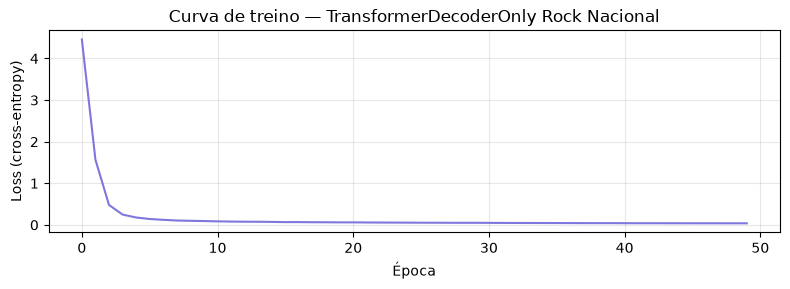

Checkpoint salvo: transformer_rock.pt


In [35]:
# Parte 8 — Treino

import matplotlib.pyplot as plt
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

EPOCHS    = 50
LR        = 0.001
CLIP_GRAD = 1.0

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.1)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS * len(dataloader))
loss_fn   = nn.CrossEntropyLoss(ignore_index=pad_id)

model.train()
history = []

for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0
    for x_batch, y_batch in dataloader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch)                                        # (B, T, V)
        loss   = loss_fn(logits.view(-1, vocab_size), y_batch.view(-1))

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    history.append(avg_loss)

    if epoch == 1 or epoch % 10 == 0:
        print(f"Época {epoch:3d}/{EPOCHS} | loss: {avg_loss:.4f} | lr: {scheduler.get_last_lr()[0]:.4f}")

print("\nTreino concluído!")

plt.figure(figsize=(8, 3))
plt.plot(history, color="#7F77DD", linewidth=1.5)
plt.xlabel("Época")
plt.ylabel("Loss (cross-entropy)")
plt.title("Curva de treino — TransformerDecoderOnly Rock Nacional")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

torch.save({
    "model_state": model.state_dict(),
    "vocab_size":  vocab_size,
    "context_len": CONTEXT_LEN,
    "d_model":     128,
    "n_heads":     4,
    "n_layers":    4,
}, "transformer_rock.pt")
print("Checkpoint salvo: transformer_rock.pt")

## Inferencia

In [38]:
# Parte 9 — Inferência

import torch.nn.functional as F

@torch.no_grad()
def generate(
    model,
    tokenizer,
    prompt: str,
    max_new_tokens: int = 80,
    strategy: str = "topk",
    temperature: float = 0.9,
    top_k: int = 40,
) -> str:
    model.eval()
    eos_id = tokenizer.token_to_id("</s>")
    enc    = tokenizer.encode(prompt.lower())
    ids    = torch.tensor([enc.ids], dtype=torch.long, device=device)

    for _ in range(max_new_tokens):
        ids_cond    = ids[:, -model.context_len:]
        next_logits = model(ids_cond)[:, -1, :]

        if strategy == "greedy":
            next_id = next_logits.argmax(dim=-1, keepdim=True)

        elif strategy == "temperature":
            probs   = F.softmax(next_logits / temperature, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)

        elif strategy == "topk":
            next_logits = next_logits / temperature
            thresh      = torch.topk(next_logits, top_k, dim=-1).values[:, -1].unsqueeze(-1)
            next_logits = next_logits.masked_fill(next_logits < thresh, float("-inf"))
            next_id     = torch.multinomial(F.softmax(next_logits, dim=-1), num_samples=1)

        else:
            raise ValueError(f"Estratégia desconhecida: {strategy!r}")

        ids = torch.cat([ids, next_id], dim=1)
        if next_id.item() == eos_id:
            break

    # Reconstrói texto a partir dos tokens BPE
    return tokenizer.decode(ids[0].tolist())


# ── Exemplos ──────────────────────────────────────────────────────────────────
for prompt in ["que país é esse", "a gente não quer", "o tempo não"]:
    for strategy in ["greedy", "temperature", "topk"]:
        result = generate(
            model, tokenizer, prompt,
            max_new_tokens=40, strategy=strategy,
            temperature=0.8, top_k=30,
        )
        print(f"[{strategy:11s}] '{prompt}' → {result}")
    print("-" * 60)
    
    # Diagnóstico — rode antes de corrigir
enc = tokenizer.encode("que país é esse")
for i, tok in zip(enc.ids, enc.tokens):
    print(f"{i:4d}  {repr(tok)}")

[greedy     ] 'que país é esse' → que país é esse Que país é esse Que país é esse
[temperature] 'que país é esse' → que país é esse Que país é esse Ter c eiro mundo se for P ia da no ex ter i or Mas o B ra s il vai ficar r ico Vamos fa tu ra r um m il h ão Quando ven
[topk       ] 'que país é esse' → que país é esse Que país é esse No A ma zo nas no A ra gua ia Na B a ixa da F l um in en se Ma to G ros so M in as G era is E no N or
------------------------------------------------------------
[greedy     ] 'a gente não quer' → a gente não quer só dinheiro A gente quer dinheiro E fel ic ida de A gente não quer só dinheiro A gente quer inte i ro E não p el a me tade Bebida é água Comida é pasto Você tem sede de
[temperature] 'a gente não quer' → a gente não quer só dinheiro A gente quer inte i ro E não p el a me tade Bebida é água Comida é pasto Você tem sede de quê Você tem fome de quê
[topk       ] 'a gente não quer' → a gente não quer só dinheiro A gente quer dinheiro E fel ic ida de A